# This Notebook

Takes the Medical Transcriptions dataset. Makes use of the "transcription" and "medical_specialty" columns, and makes a classifier to predict speciality.

Settings used:
- Preprocessing:
    - ✅ Normalization (Lowercasing, Normalizing Unicode, Tons of Regex)
    - ✅ Tokenization (Mandatory)
    - ❌ Stopword removal (Not recommended cause it discards information), can be enabled.
    - ✅ Lemmatization (we are interested in proper nouns, so rest can be normalized)
- N-Gram: (1,2) is used. Can be experimented with using other settings.
- Classifier: SVM (LinearSVC) used. Can be experimented with using other classifiers.

## Dependencies

In [1]:
# !pip install unidecode nltk scikit-learn seaborn kagglehub

## Imports

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import os
import re
from pathlib import Path
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from typing import Callable, Any
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

## Load Dataset

In [3]:
dataset_path = kagglehub.dataset_download('tboyle10/medicaltranscriptions')

medical_transcriptions = pd.read_csv(os.path.join(dataset_path, 'mtsamples.csv'))

medical_transcriptions

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."
...,...,...,...,...,...,...
4994,4994,Patient having severe sinusitis about two to ...,Allergy / Immunology,Chronic Sinusitis,"HISTORY:, I had the pleasure of meeting and e...",NaN
4995,4995,This is a 14-month-old baby boy Caucasian who...,Allergy / Immunology,Kawasaki Disease - Discharge Summary,"ADMITTING DIAGNOSIS: , Kawasaki disease.,DISCH...","allergy / immunology, mucous membranes, conjun..."
4996,4996,A female for a complete physical and follow u...,Allergy / Immunology,Followup on Asthma,"SUBJECTIVE: , This is a 42-year-old white fema...",NaN
4997,4997,Mother states he has been wheezing and coughing.,Allergy / Immunology,Asthma in a 5-year-old,"CHIEF COMPLAINT: , This 5-year-old male presen...",NaN


In [4]:
def consolidate_speciality(base_df: pd.DataFrame, classes: list[str], new_speciality: str):
    filtered_df = base_df[base_df['medical_specialty'].str.strip().isin(classes)].copy()
    filtered_df['specialty'] = new_speciality
    return filtered_df

def trim_down(base_df: pd.DataFrame, count: int, shuffle: bool = True):
    if shuffle:
        return base_df.sample(n = count, random_state = 42).reset_index(drop = True).copy()
    else:
        return base_df[:count].copy()

## We classify a subset of distinct specialties among vast specialty distribution

In [ ]:
regrouped_df = pd.concat([
    consolidate_speciality(
        medical_transcriptions,
        ['Gastroenterology'],
        'Gastroenterology'
    ),


    consolidate_speciality(
        medical_transcriptions,
        ['Neurology'],
        'Neurology'
    ),

    trim_down(
        consolidate_speciality(
            medical_transcriptions,
            ['Cardiovascular / Pulmonary'],
            'Cardiovascular / Pulmonary'
        ),
        count = 240
    ),

    consolidate_speciality(
        medical_transcriptions,
        ['Ophthalmology'],
        'Ophthalmology'
    ),

    consolidate_speciality(
        medical_transcriptions,
        ['Obstetrics / Gynecology'],
        'Obstetrics / Gynecology'
    ),

    consolidate_speciality(
        medical_transcriptions, 
        ['Orthopedic'],
        'Orthopedic'
    ),

    consolidate_speciality(
        medical_transcriptions, 
        ['General Medicine'],
        'General Medicine'
    ),
    consolidate_speciality(
        medical_transcriptions,
        ['Urology'],
        'Urology'
    ),
    consolidate_speciality(
        medical_transcriptions, 
        ['ENT - Otolaryngology'],
        'ENT - Otolaryngology'
    ),
    consolidate_speciality(
        medical_transcriptions, 
        ['Pain Management'],
        'Pain Management'
    ),    
    consolidate_speciality(
        medical_transcriptions, 
        ['Psychiatry / Psychology'],
        'Psychiatry / Psychology'
    ),
], ignore_index = True, sort = False)

regrouped_df

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,specialty
0,3455,This is a pleasant 50-year-old female who has...,Gastroenterology,Wound Check - Status Post APR,"HISTORY OF PRESENT ILLNESS:, Ms. Connor is a ...","gastroenterology, perineal wound, wound infect...",Gastroenterology
1,3456,Upper endoscopy with foreign body removal (Pe...,Gastroenterology,Upper Endoscopy - Foreign Body Removal,"PROCEDURE:, Upper endoscopy with foreign body ...","gastroenterology, upper endoscopy, endoscopy, ...",Gastroenterology
2,3458,Umbilical hernia repair. A standard curviline...,Gastroenterology,Umbilical Hernia Repair - 1,"PROCEDURE PERFORMED: , Umbilical hernia repair...","gastroenterology, fascial defect, umbilical he...",Gastroenterology
3,3462,Viral gastroenteritis. Patient complaining o...,Gastroenterology,Viral Gastroenteritis,"HISTORY OF PRESENT ILLNESS: , Patient is a 40-...","gastroenterology, nausea, vomiting, viral gast...",Gastroenterology
4,3463,Upper endoscopy with removal of food impaction.,Gastroenterology,Upper Endoscopy,"PROCEDURE:, Upper endoscopy with removal of f...","gastroenterology, dysphagia, removal of food i...",Gastroenterology
...,...,...,...,...,...,...,...
1916,1807,"The patient has a manic disorder, is presentl...",Psychiatry / Psychology,Bipolar Affective Disorder - Consult,"IDENTIFYING DATA: ,The patient is a 35-year-o...",NaN,Psychiatry / Psychology
1917,1808,"The patient is a 21-year-old Caucasian male, ...",Psychiatry / Psychology,Attempted Suicide - Consult,"IDENTIFYING DATA: , The patient is a 21-year-o...",NaN,Psychiatry / Psychology
1918,1812,School reports continuing difficulties with r...,Psychiatry / Psychology,Asperger Disorder,"SUBJECTIVE: ,School reports continuing diffic...","psychiatry / psychology, repetitive questionin...",Psychiatry / Psychology
1919,1814,The patient was referred due to concerns rega...,Psychiatry / Psychology,Adjustment Disorder & Encopresis,"REASON FOR REFERRAL:, The patient was referre...","psychiatry / psychology, developmental backgro...",Psychiatry / Psychology


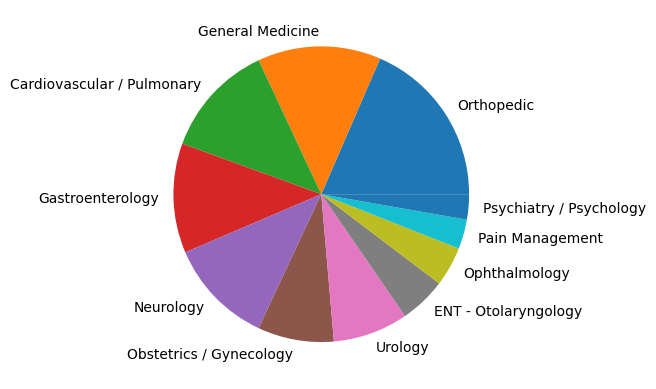

In [6]:
speciality_dist = regrouped_df['specialty'].value_counts().to_dict()

speciality_names = list(speciality_dist.keys())
speciality_counts = [speciality_dist[s] for s in speciality_names]

fig, ax = plt.subplots()
ax.pie(speciality_counts, labels = speciality_names)
plt.show()

## Labelise Specialties

In [7]:
regrouped_df['label'] = regrouped_df['specialty'].map(lambda s : speciality_names.index(s))

## Define Preprocessor

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_medical_transcript(text: str) -> str:

    text = unidecode(text)

    # 1. Standardize case and strip line breaks/tabs
    text = text.lower()
    text = re.sub(r'[\r\n\t]', ' ', text)
    
    # 2. Remove universal formatting noise (duplicate commas, list numbers like "1. ", "2. ")
    text = re.sub(r',\s*,', ' ', text)
    text = re.sub(r'\b\d+\.\s+', ' ', text)

    # 3. Standardize symbols that carry universal clinical meaning
    text = text.replace('%', ' percent ')

    # 4. Abstract ALL numerical values (weights, dosages, dimensions, vitals)
    # This prevents your TF-IDF vocabulary from bloating with thousands of unique numbers
    text = re.sub(r'\b\d+(?:\.\d+)?\b', ' [num] ', text)

    # 5. Universal Punctuation Stripper
    # Keeps only lowercase letters, numbers, spaces, and our placeholder brackets.
    # This naturally handles hyphens (e.g., "beta-blocker" -> "beta blocker", "2-d" -> "2 d")
    text = re.sub(r'[^a-z0-9\[\]\s]', ' ', text)
    
    # 6. Collapse duplicate spaces
    text = " ".join(text.split())

    return text

def remove_stopwords(tokens: list[str]) -> list[str]:
    return list(
        filter(
            lambda t : t not in stop_words and len(t) > 1,
            tokens
        )
    )

def lemmatize(tokens: list[str]) -> list[str]:
    return list(
        map(
            lambda t: lemmatizer.lemmatize(t),
            tokens
        )
    )

class TextPreprocessor:
    transformations: list[Callable]

    def __init__(self) -> None:
        self.transformations = []

    def add(self, tfomer: Callable):
        self.transformations.append(tfomer)
        return self

    def __call__(self, sample: str) -> Any:
        for tform in self.transformations:
            sample = tform(sample)
        return sample

## Init Preprocessor and Vectoriser 

In [9]:
preprocessor = TextPreprocessor() \
    .add(preprocess_medical_transcript) \
    .add(nltk.word_tokenize) \
    .add(lemmatize)
    # .add(remove_stopwords) \

vectorizer_tfidf = TfidfVectorizer(
    lowercase     = False, # already handled
    tokenizer     = preprocessor,

    stop_words    = None, # again, already handled
    ngram_range   = (1, 3),
    token_pattern = None, # pyright: ignore[reportArgumentType]

    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True,
    max_features=50000
)

## Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(regrouped_df['transcription'], regrouped_df['label'], test_size = 0.2, random_state = 42, stratify = regrouped_df['label'])

## Vectorise

In [11]:
train_tfidf = vectorizer_tfidf.fit_transform(X_train.values.astype('U'))
test_tfidf  = vectorizer_tfidf.transform(X_test.values.astype('U'))

## Train

In [12]:
clf_svc = LinearSVC(C = 10 , class_weight = 'balanced', random_state = 42)
clf_svc.fit(X = train_tfidf, y = y_train.to_list())

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,10
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


## Show Performance

In [13]:
test_pred = clf_svc.predict(X = test_tfidf)
print(classification_report(y_test.to_list(), test_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87        71
           1       0.63      0.83      0.72        52
           2       0.76      0.73      0.74        48
           3       0.84      0.70      0.76        46
           4       0.76      0.58      0.66        45
           5       0.88      0.88      0.88        32
           6       0.94      0.94      0.94        32
           7       0.86      0.90      0.88        20
           8       1.00      1.00      1.00        17
           9       0.89      0.67      0.76        12
          10       0.80      0.80      0.80        10

    accuracy                           0.81       385
   macro avg       0.84      0.81      0.82       385
weighted avg       0.81      0.81      0.80       385



In [14]:
regrouped_df['specialty'].value_counts()

specialty
Orthopedic                    355
General Medicine              259
Cardiovascular / Pulmonary    240
Gastroenterology              230
Neurology                     223
Obstetrics / Gynecology       160
Urology                       158
ENT - Otolaryngology           98
Ophthalmology                  83
Pain Management                62
Psychiatry / Psychology        53
Name: count, dtype: int64

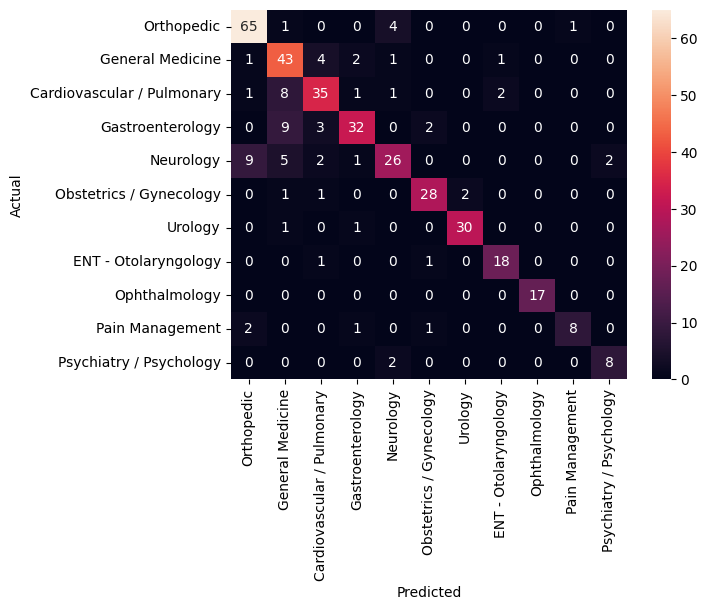

In [15]:
conf_mat = confusion_matrix(y_true = y_test.to_numpy(), y_pred = test_pred)
ticklabels = speciality_names
sns.heatmap(conf_mat, annot = True, fmt = 'd', xticklabels = ticklabels, yticklabels = ticklabels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Test some examples

In [16]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['Daily epigastric burning, postprandial bloating, early satiety. No weight loss, dysphagia, or bleeding. Prior negative H. pylori breath test.']))
speciality_names[ipred[0]]

'General Medicine'

In [17]:
ipred = clf_svc.predict(X = vectorizer_tfidf.transform(['Reports intermenstrual spotting and heavy flow every 24-28 days lasting 7-9 days. No pelvic pain, dyspareunia, or postcoital bleeding. LMP 05/10/2026.']))
speciality_names[ipred[0]]

'Obstetrics / Gynecology'

## Serialize Objects

Put the necessary objects in dictionary for exporting

In [18]:
save_object = {
    'classes':    speciality_names,
    'vectorizer': vectorizer_tfidf,
    'classifier': clf_svc
}

save_object

{'classes': ['Orthopedic',
  'General Medicine',
  'Cardiovascular / Pulmonary',
  'Gastroenterology',
  'Neurology',
  'Obstetrics / Gynecology',
  'Urology',
  'ENT - Otolaryngology',
  'Ophthalmology',
  'Pain Management',
  'Psychiatry / Psychology'],
 'vectorizer': TfidfVectorizer(lowercase=False, max_df=0.95, max_features=50000, min_df=2,
                 ngram_range=(1, 3), sublinear_tf=True, token_pattern=None,
                 tokenizer=<__main__.TextPreprocessor object at 0x0000024A9D64D010>),
 'classifier': LinearSVC(C=10, class_weight='balanced', random_state=42)}

## Save the Classifier Suite

export the classifier and vectorizer as serialized joblib object so that the streamlit application can load it.

In [19]:
ROOT_DIR = Path(os.path.abspath('')).resolve().parent
APP_DIR = ROOT_DIR / 'web_app-integrated'

joblib.dump(save_object, str(APP_DIR / 'specialty_classifier_objects.joblib'))

['D:\\Academic\\AdvNLP\\Project\\GitHub\\COMP8420-Group-L-Healthcare\\web_app-integrated\\specialty_classifier_objects.joblib']